# Step 3 Hybrid Decision System
**Rule-Based Connectivity Mode Selection for Disaster-Resilient Agri-IoT**

This notebook determines the optimal connectivity mode every 30 minutes based on LoRaWAN PDR and LEO satellite availability. Three scenarios are evaluated: baseline (normal operation), light stress, and heavy stress.

In [ ]:
import numpy as np
import heapq
import pandas as pd
import matplotlib.pyplot as plt
import os

# Simulation constants (must match Step 1 and Step 2)
# From step 1 LoRaWAN Simulation
SIM_DURATION    = 86400
AREA_RADIUS_KM  = np.sqrt(53.0 / np.pi)
CHANNEL_NUM     = 8
TX_DBM          = 14
SENS_DBM        = {7: -123.0, 9: -129.0, 12: -137.0}
PL_EXP          = 2.34
PL_D0_KM        = 0.001
PL_D0_DB        = 31.5
SHADOW_STD      = 7.0
WINDOW_S        = 1800

# From step 2 LEO Satellite Simulation
ALTITUDE_KM     = 550.0
FREQ_GHZ        = 12.0
EARTH_RADIUS_KM = 6371.0
ELEV_MIN_DEG    = 25.0
EIRP_DBM        = 61.5
RX_GAIN_DBI     = 33.2
MISC_LOSS_DB    = 2.0
SAT_SENS_DBM    = -89.0
RAIN_K          = (0.0188 + 0.0168) / 2
RAIN_ALPHA      = (0.0188 * 1.217 + 0.0168 * 1.200) / (2 * RAIN_K)

WEATHER_STATES = {
    'clear':    (0.0,  0.0),
    'light':    (0.1,  9.9),
    'moderate': (10.0, 29.9),
    'heavy':    (30.0, 50.0),
}
W_NAMES = list(WEATHER_STATES.keys())
TRANSITION_MATRIX = {
    'clear':    [0.995, 0.005, 0.0,  0.0 ],
    'light':    [0.05,  0.90,  0.05, 0.0 ],
    'moderate': [0.01,  0.10,  0.80, 0.09],
    'heavy':    [0.0,   0.05,  0.15, 0.80],
}
WEATHER_ENCODE = {'clear': 0, 'light': 1, 'moderate': 2, 'heavy': 3}

# Decision thresholds
PDR_HIGH  = 0.90
PDR_LOW   = 0.35
SAT_OK_TH = 0.70

print("Constants loaded.")
print(f"Decision thresholds: PDR_HIGH={PDR_HIGH} | PDR_LOW={PDR_LOW} | SAT_OK={SAT_OK_TH}")

Constants loaded.
Decision thresholds: PDR_HIGH=0.9 | PDR_LOW=0.35 | SAT_OK=0.7


## Rule-Based Decision Function

In [2]:
def rule_based_decision(row):
    pdr  = row['pdr_lorawan']
    s_ok = row['sat_availability'] >= SAT_OK_TH

    if pdr >= PDR_HIGH:
        return 'lorawan_only'
    elif pdr >= PDR_LOW and s_ok:
        return 'hybrid'
    elif pdr >= PDR_LOW and not s_ok:
        return 'lorawan_only'
    elif pdr < PDR_LOW and s_ok:
        return 'satellite_only'
    else:
        return 'hybrid'

print("Rule-based decision function ready.")

Rule-based decision function ready.


## Simulation Functions

In [3]:
class IoTNode:
    def __init__(self, node_id, distance):
        self.node_id = node_id
        self.distance_to_gw = distance


def time_on_air_s(sf, payload_bytes=30):
    symbol_time = (2 ** sf) / 125000.0
    de = 1 if sf >= 11 else 0
    n_symbols = 8 + max(0, (8 * payload_bytes - 4 * sf + 28 + 16) // (4 * (sf - 2 * de)) * 5)
    return (8 + 4.25 + n_symbols) * symbol_time


def place_nodes(n, radius_km, rng):
    nodes = []
    for i in range(n):
        angle = rng.uniform(0, 2 * np.pi)
        r = radius_km * np.sqrt(rng.uniform(0, 1))
        nodes.append(IoTNode(i, r))
    return nodes


def run_lorawan_scenario(num_nodes, sf, tx_interval, seed=42):
    rng = np.random.default_rng(seed)
    tx_dur = time_on_air_s(sf)
    nodes = place_nodes(num_nodes, AREA_RADIUS_KM, rng)

    eq = []
    counter = 0
    for node in nodes:
        t0 = rng.exponential(tx_interval)
        heapq.heappush(eq, (t0, counter, node))
        counter += 1

    active = {ch: [] for ch in range(CHANNEL_NUM)}
    log = []

    while eq:
        t, _, node = heapq.heappop(eq)
        if t > SIM_DURATION:
            break
        ch = int(rng.integers(0, CHANNEL_NUM))
        active[ch] = [(et, nid) for et, nid in active[ch] if et > t]
        collision = len(active[ch]) > 0
        d = max(node.distance_to_gw, PL_D0_KM)
        pl = PL_D0_DB + 10 * PL_EXP * np.log10(d / PL_D0_KM) + rng.normal(0, SHADOW_STD)
        rssi = TX_DBM - pl
        signal_ok = rssi >= SENS_DBM[sf]
        success = (not collision) and signal_ok
        log.append({'time': t, 'success': success, 'collision': collision,
                    'rssi_dbm': rssi, 'spreading_factor': sf})
        active[ch].append((t + tx_dur, node.node_id))
        nt = t + rng.exponential(tx_interval)
        if nt <= SIM_DURATION:
            heapq.heappush(eq, (nt, counter, node))
            counter += 1

    df = pd.DataFrame(log)
    df['window'] = (df['time'] // WINDOW_S).astype(int)
    windows = df.groupby('window').agg(
        pdr_lorawan=('success', 'mean'),
        collision_rate=('collision', 'mean'),
        mean_rssi_lorawan=('rssi_dbm', 'mean'),
    ).reset_index()
    windows['spreading_factor'] = sf
    return windows, df['success'].mean()


def run_satellite_scenario(seed=42):
    rng = np.random.default_rng(seed)
    state = 'clear'
    log = []

    for t in np.arange(0, SIM_DURATION, 30):
        low, high = WEATHER_STATES[state]
        rain = rng.uniform(low, high)

        max_ang = np.degrees(
            np.pi / 2 - np.radians(ELEV_MIN_DEG) -
            np.arcsin((EARTH_RADIUS_KM / (EARTH_RADIUS_KM + ALTITUDE_KM)) *
                      np.cos(np.radians(ELEV_MIN_DEG)))
        )
        ca = rng.beta(1.0, 2.2) * max_ang
        gamma = np.radians(ca)
        re, rs = EARTH_RADIUS_KM, EARTH_RADIUS_KM + ALTITUDE_KM
        elev = np.degrees(np.arctan2(np.cos(gamma) - (re / rs), np.sin(gamma)))

        if elev < ELEV_MIN_DEG:
            log.append({'time': t, 'weather_state': state, 'rain_rate_mmhr': rain,
                        'success': False, 'latency_ms': np.nan, 'rssi_dbm': np.nan})
        else:
            dist = -re * np.sin(np.radians(elev)) + np.sqrt(
                (re * np.sin(np.radians(elev))) ** 2 + ALTITUDE_KM ** 2 + 2 * ALTITUDE_KM * re)
            fspl = 20 * np.log10(dist) + 20 * np.log10(FREQ_GHZ * 1000) + 32.44
            rain_att = 0.0
            if rain > 0:
                leff = 4.86 / np.sin(np.radians(max(elev, 5.0)))
                rain_att = max(0.0, RAIN_K * (rain ** RAIN_ALPHA) * leff *
                               max(0, rng.normal(1, 0.15)))
            rssi = EIRP_DBM - fspl - rain_att - MISC_LOSS_DB + RX_GAIN_DBI
            ok = rssi >= SAT_SENS_DBM
            prop = (dist / 299792.458) * 1000 * 2
            proc = max(5.0, rng.normal(59.25 - prop, 31.75))
            penalty = rng.exponential(rain_att * 15) if rain_att > 3 else 0.0
            lat = max(5.0, prop + proc + penalty) if ok else np.nan
            log.append({'time': t, 'weather_state': state, 'rain_rate_mmhr': rain,
                        'success': ok, 'latency_ms': lat, 'rssi_dbm': rssi})

        probs = TRANSITION_MATRIX[state]
        state = rng.choice(W_NAMES, p=probs)

    df = pd.DataFrame(log)
    df['window'] = (df['time'] // WINDOW_S).astype(int)
    windows = df.groupby('window').agg(
        sat_availability=('success', 'mean'),
        sat_latency_ms=('latency_ms', 'mean'),
        sat_rssi_dbm=('rssi_dbm', 'mean'),
        rain_rate_mmhr=('rain_rate_mmhr', 'mean'),
    ).reset_index()
    weather_mode = df.groupby('window')['weather_state'].agg(lambda x: x.mode()[0])
    windows['weather_encoded'] = weather_mode.map(WEATHER_ENCODE).values
    windows['sat_latency_ms'] = windows['sat_latency_ms'].fillna(9999)
    return windows

print("Simulation functions ready.")

Simulation functions ready.


## Baseline Inference

Runs the decision system on the baseline configuration (SF9, 500 nodes, TX 3600s).
If CSV files from Step 1 and Step 2 are available, they will be used directly.

In [4]:
print("=== Baseline Inference (24-hour simulation) ===")

required = ['lorawan_windows.csv', 'satellite_windows.csv']
use_csv = all(os.path.exists(f) for f in required)

if use_csv:
    df_lora_infer = pd.read_csv('lorawan_windows.csv')
    df_sat_infer  = pd.read_csv('satellite_windows.csv')
    print("Loaded CSV files from Step 1 and Step 2.")
else:
    print("CSV files not found. Running simulation directly.")
    df_lora_infer, _ = run_lorawan_scenario(num_nodes=500, sf=9, tx_interval=3600, seed=42)
    df_sat_infer      = run_satellite_scenario(seed=42)

df_infer = df_lora_infer.merge(df_sat_infer, on='window', how='inner')
df_infer['t_start_hr']   = df_infer['window'] * (WINDOW_S / 3600)
df_infer['decision_rule'] = df_infer.apply(rule_based_decision, axis=1)

total = len(df_infer)
dist  = df_infer['decision_rule'].value_counts()

print(f"\nTotal windows : {total}")
for mode in ['lorawan_only', 'hybrid', 'satellite_only']:
    count = dist.get(mode, 0)
    print(f"  {mode:<20}: {count} windows ({count / total:.1%})")

=== Baseline Inference (24-hour simulation) ===
CSV files not found. Running simulation directly.

Total windows : 48
  lorawan_only        : 48 windows (100.0%)
  hybrid              : 0 windows (0.0%)
  satellite_only      : 0 windows (0.0%)


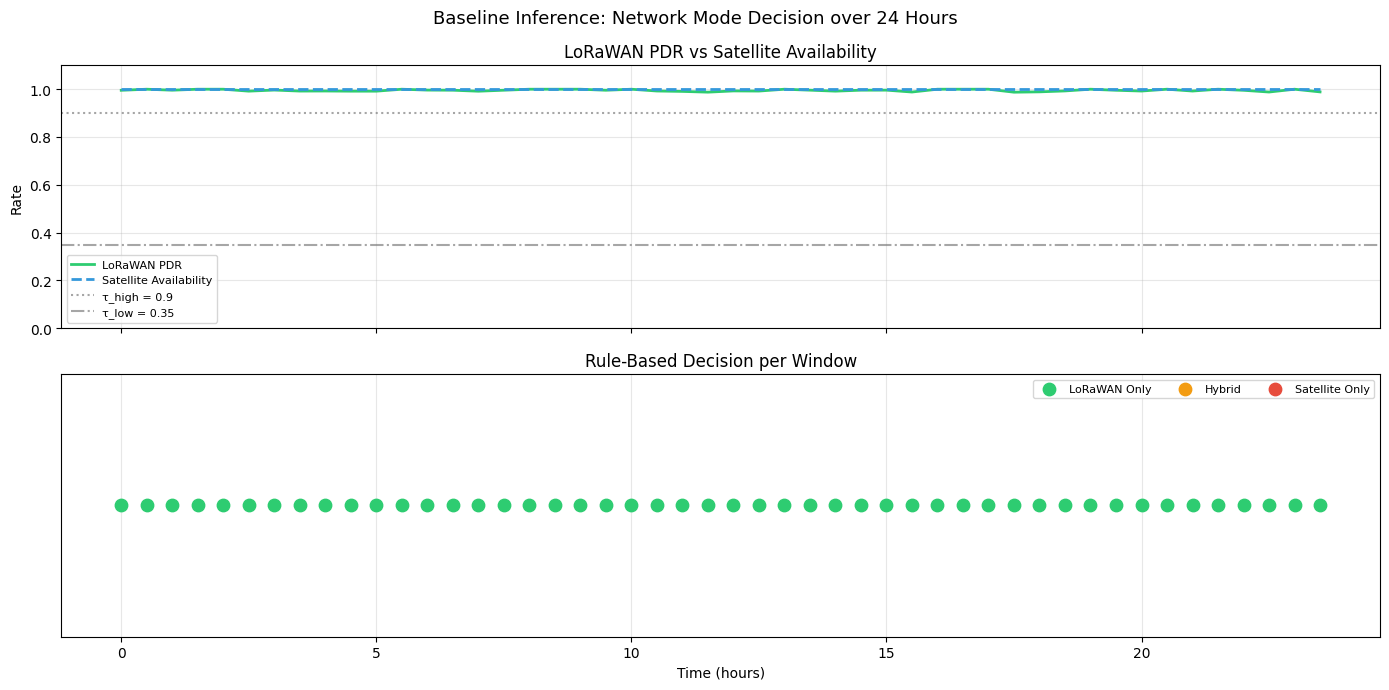

Saved step3_baseline_inference.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Baseline Inference: Network Mode Decision over 24 Hours", fontsize=13)

t = df_infer['t_start_hr']
lbl_colors = {'lorawan_only': '#2ecc71', 'hybrid': '#f39c12', 'satellite_only': '#e74c3c'}
lbl_labels = {'lorawan_only': 'LoRaWAN Only', 'hybrid': 'Hybrid', 'satellite_only': 'Satellite Only'}

ax = axes[0]
ax.plot(t, df_infer['pdr_lorawan'],      color='#2ecc71', lw=2, label='LoRaWAN PDR')
ax.plot(t, df_infer['sat_availability'], color='#3498db', lw=2, ls='--', label='Satellite Availability')
ax.axhline(PDR_HIGH, color='gray', ls=':',  alpha=0.7, label=f'τ_high = {PDR_HIGH}')
ax.axhline(PDR_LOW,  color='gray', ls='-.', alpha=0.7, label=f'τ_low = {PDR_LOW}')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_title('LoRaWAN PDR vs Satellite Availability')

ax = axes[1]
for lbl, color in lbl_colors.items():
    mask = df_infer['decision_rule'] == lbl
    ax.scatter(t[mask], [0.5] * mask.sum(), c=color, s=80,
               marker='o', label=lbl_labels[lbl], zorder=3)
ax.set_yticks([])
ax.set_xlabel('Time (hours)')
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
ax.set_title('Rule-Based Decision per Window')

plt.tight_layout()
plt.savefig('step3_baseline_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved step3_baseline_inference.png")

In [6]:
output_cols = ['window', 't_start_hr', 'pdr_lorawan', 'collision_rate',
               'sat_availability', 'sat_latency_ms', 'rain_rate_mmhr',
               'weather_encoded', 'decision_rule']
df_infer[output_cols].to_csv('step3_inference_decisions.csv', index=False)
print("Saved step3_inference_decisions.csv")

Saved step3_inference_decisions.csv


## Decision Mode Distribution: Three Scenarios

Evaluates the rule-based decision system under three configurations to demonstrate
how the switching mechanism responds to increasing network stress.

In [7]:
print("=== Decision Mode Distribution: Three Scenarios ===")

scenarios = [
    ('Baseline',     500,  9,  3600),
    ('Light Stress', 1000, 12, 1800),
    ('Heavy Stress', 1000, 12,  900),
]

sat_windows    = run_satellite_scenario(seed=42)
results_table  = []

for name, nodes, sf, tx in scenarios:
    lora_windows, mean_pdr = run_lorawan_scenario(
        num_nodes=nodes, sf=sf, tx_interval=tx, seed=42)

    merged = lora_windows.merge(sat_windows, on='window', how='inner')
    merged['mode'] = merged.apply(rule_based_decision, axis=1)

    total = len(merged)
    dist  = merged['mode'].value_counts()

    results_table.append({
        'Scenario':       name,
        'Configuration':  f'SF{sf}, {nodes} nodes, TX {tx}s',
        'Mean PDR':       f"{mean_pdr:.2%}",
        'LoRaWAN-only':   f"{dist.get('lorawan_only', 0) / total:.1%}",
        'Hybrid':         f"{dist.get('hybrid', 0) / total:.1%}",
        'Satellite-only': f"{dist.get('satellite_only', 0) / total:.1%}",
    })

    print(f"\n{name} ({nodes} nodes, SF{sf}, TX {tx}s)")
    print(f"  Mean PDR      : {mean_pdr:.2%}")
    print(f"  Total windows : {total}")
    for mode in ['lorawan_only', 'hybrid', 'satellite_only']:
        count = dist.get(mode, 0)
        print(f"  {mode:<20}: {count} windows ({count / total:.1%})")

print("\n" + "=" * 65)
df_results = pd.DataFrame(results_table)
print(df_results.to_string(index=False))
df_results.to_csv('step3_scenario_comparison.csv', index=False)
print("\nSaved step3_scenario_comparison.csv")

=== Decision Mode Distribution: Three Scenarios ===

Baseline (500 nodes, SF9, TX 3600s)
  Mean PDR      : 99.52%
  Total windows : 48
  lorawan_only        : 48 windows (100.0%)
  hybrid              : 0 windows (0.0%)
  satellite_only      : 0 windows (0.0%)

Light Stress (1000 nodes, SF12, TX 1800s)
  Mean PDR      : 90.18%
  Total windows : 48
  lorawan_only        : 30 windows (62.5%)
  hybrid              : 18 windows (37.5%)
  satellite_only      : 0 windows (0.0%)

Heavy Stress (1000 nodes, SF12, TX 900s)
  Mean PDR      : 81.28%
  Total windows : 48
  lorawan_only        : 0 windows (0.0%)
  hybrid              : 48 windows (100.0%)
  satellite_only      : 0 windows (0.0%)

    Scenario              Configuration Mean PDR LoRaWAN-only Hybrid Satellite-only
    Baseline   SF9, 500 nodes, TX 3600s   99.52%       100.0%   0.0%           0.0%
Light Stress SF12, 1000 nodes, TX 1800s   90.18%        62.5%  37.5%           0.0%
Heavy Stress  SF12, 1000 nodes, TX 900s   81.28%        

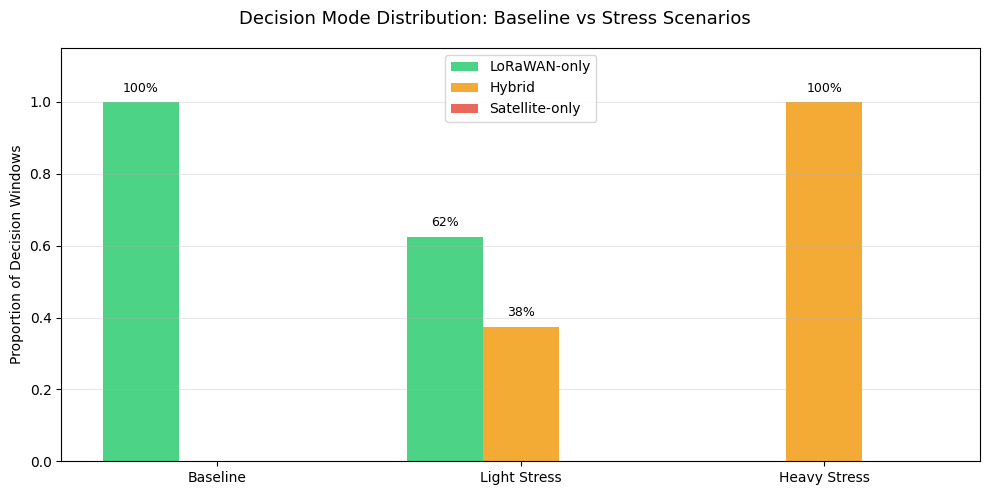

Saved step3_scenario_comparison.png


: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Decision Mode Distribution: Baseline vs Stress Scenarios", fontsize=13)

scenario_names = [r['Scenario'] for r in results_table]
lorawan_vals   = [float(r['LoRaWAN-only'].strip('%')) / 100 for r in results_table]
hybrid_vals    = [float(r['Hybrid'].strip('%')) / 100 for r in results_table]
satellite_vals = [float(r['Satellite-only'].strip('%')) / 100 for r in results_table]

x     = np.arange(len(scenario_names))
width = 0.25

bars1 = ax.bar(x - width, lorawan_vals,   width, label='LoRaWAN-only',   color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x,         hybrid_vals,    width, label='Hybrid',          color='#f39c12', alpha=0.85)
bars3 = ax.bar(x + width, satellite_vals, width, label='Satellite-only',  color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(scenario_names)
ax.set_ylabel('Proportion of Decision Windows')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                    f'{h:.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('step3_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved step3_scenario_comparison.png")